In [2]:
import os
from copy import deepcopy

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.interpolate import interp1d
from tqdm import tqdm
import seaborn as sns
from pathlib import Path

import lifesim
from lifesim.util.habitable import single_habitable_zone


In [3]:
import os, sys
os.chdir("/home/kirschkobold/documents/life_internship/LIFEsim_yields")
sys.path.insert(0, os.getcwd())

# 1. Reproduce 'per optimization' plot

In [4]:
def interpolate_diameter(source_path):
    subdirs = [d for d in os.listdir(source_path) if os.path.isdir(os.path.join(source_path, d))]
    diams_float = [float('.'.join(d.split('_')[1:])) for d in subdirs]
    diams = ['_'.join(d.split('_')[1:]) for d in subdirs]

    # uu = upper uncertainty, lu = lower uncertainty
    mission_time = pd.DataFrame(index=np.sort(diams_float), columns=['mission_time_mean', 'lu_mission_time', 'uu_mission_time', 'mission_time_opt_factor'])

    for subdir, d in zip(subdirs, diams_float):
        data_path = os.path.join(source_path, subdir)
        # read the csv file in data path that ends with _mission_time.csv, return error if multiple or none found
        csv_files = [f for f in os.listdir(data_path) if f.endswith('_mission_time.csv')]
        if len(csv_files) != 1:
            raise ValueError(f'Expected one _mission_time.csv file in {data_path}, found {len(csv_files)}')
        data = pd.read_csv(os.path.join(data_path, csv_files[0]))
        mission_time.loc[d, 'mission_time_mean'] = data['total'].mean()
        mission_time.loc[d, 'lu_mission_time'] = data['total'].mean() - data['total'].quantile(0.16)
        mission_time.loc[d, 'uu_mission_time'] = data['total'].quantile(0.84) - data['total'].mean()
        det_ratio = data['detection'] / (data['total'])
        mission_time.loc[d, 'detection_ratio_mean'] = det_ratio.mean()
        mission_time.loc[d, 'lu_detection_ratio'] = det_ratio.mean() - det_ratio.quantile(0.16)
        mission_time.loc[d, 'uu_detection_ratio'] = det_ratio.quantile(0.84) - det_ratio.mean()

        if 'n_Experiment_1' in data.columns:
            mission_time.loc[d, 'mission_time_opt_factor'] = data.loc[data['n_Experiment_1'] == data['n_Experiment_1'].max(), 'total'].mean()
        else:
            mission_time.loc[d, 'mission_time_opt_factor'] = data.loc[data['n_Experiment_2'] == data['n_Experiment_2'].max(), 'total'].mean()

    max_times = np.arange(0.5, 20.1, 0.5)

    max_time_table = pd.DataFrame(index=np.sort(max_times), columns=['diameter_mean', 'lu_diameter', 'uu_diameter', 'diameter_opt_factor'])

    n = len(mission_time)
    kind = 'cubic' if n >= 4 else 'quadratic' if n >= 3 else 'linear'
    # make a spline interpolation of all data points in mission time data frame and evaluate at max_times
    spline = interp1d(np.array(mission_time['mission_time_mean'] / 365.25 / 24 / 60 / 60, dtype=float), np.array(mission_time.index, dtype=float), kind=kind, fill_value='extrapolate')
    max_time_table['diameter_mean'] = spline(max_times)
    # for uncertainties, do linear interpolation of upper and lower bounds
    spline_lu = interp1d(np.array((mission_time['mission_time_mean'] - mission_time['lu_mission_time']) / 365.25 / 24 / 60 / 60, dtype=float), np.array(mission_time.index, dtype=float), kind='linear', fill_value='extrapolate')
    spline_uu = interp1d(np.array((mission_time['mission_time_mean'] + mission_time['uu_mission_time']) / 365.25 / 24 / 60 / 60, dtype=float), np.array(mission_time.index, dtype=float), kind='linear', fill_value='extrapolate')
    max_time_table['lu_diameter'] = max_time_table['diameter_mean'] - spline_lu(max_times)
    max_time_table['uu_diameter'] = spline_uu(max_times) - max_time_table['diameter_mean']
    # for optimal factor diameters
    spline_opt = interp1d(np.array(mission_time['mission_time_opt_factor'] / 365.25 / 24 / 60 / 60, dtype=float), np.array(mission_time.index, dtype=float), kind=kind, fill_value='extrapolate')
    max_time_table['diameter_opt_factor'] = spline_opt(max_times)

    # save max time table to csv
    max_time_table.to_csv(os.path.join(source_path, source_path.split('/')[-1] + '_diameter_mission_time.csv'))
    mission_time.to_csv(os.path.join(source_path, source_path.split('/')[-1] + '_diameter_mission_time_RAW.csv'))

In [5]:
# run the interpolation on all opt_ directories in the given path
path = "/home/kirschkobold/documents/life_internship/LIFEsim_yields/euler_data"

# find all subdirectories (and subsub, and so on) in path that start with 'opt_'
opt_dirs = []
for root, dirs, files in os.walk(path):
    for dirname in dirs:
        if dirname.startswith('opt_'):
            opt_dirs.append(os.path.join(root, dirname))

for opt_dir in opt_dirs:
    interpolate_diameter(opt_dir)

In [6]:
def _get_diams_catalog(source_path):
    subdirs = [d for d in os.listdir(source_path) if os.path.isdir(os.path.join(source_path, d)) if d.startswith('opt_')]
    opt_names = [d.removeprefix('opt_') for d in subdirs]

    diam_time_tables = {}
    for subdir, opt_name in zip(subdirs, opt_names):
        data_path = os.path.join(source_path, subdir)
        diam_time_tables[opt_name] = pd.read_csv(os.path.join(data_path, subdir + '_diameter_mission_time.csv'), index_col=0)
        diam_time_tables[opt_name][diam_time_tables[opt_name] < 0] = np.nan  # set negative values to nan

    # sort opt_name by mean diameter at 10 years
    diam_time_tables = dict(sorted(diam_time_tables.items(), key=lambda item: item[1].loc[10, 'diameter_mean']))

    return diam_time_tables

In [7]:
def _get_eff_eta(catalog_path,
                 config_path="/home/kirschkobold/documents/life_internship/LIFEsim_yields/optimizer_config.yaml"):
    bus = lifesim.Bus()

    # setting the options
    bus.build_from_config(filename=config_path)
    bus.data.import_catalog(input_path=catalog_path)

    (bus.data.catalog.s_in,
     bus.data.catalog.s_out,
     bus.data.catalog.l_sun,
     bus.data.catalog.hz_in,
     bus.data.catalog.hz_out,
     bus.data.catalog.hz_center) = single_habitable_zone(model='Kopparapu-Conservative',
                                                         temp_s=bus.data.catalog.temp_s,
                                                         radius_s=bus.data.catalog.radius_s)

    bus.data.catalog.habitable = np.logical_and.reduce((
        (bus.data.catalog['semimajor_p'] > bus.data.catalog['hz_in']).to_numpy(),
        (bus.data.catalog['semimajor_p'] < bus.data.catalog['hz_out']).to_numpy(),
        (bus.data.catalog['radius_p'].ge(0.8*(bus.data.catalog.semimajor_p/np.sqrt(bus.data.catalog.l_sun))**(-0.5))).to_numpy(),
        (bus.data.catalog['radius_p'].le(1.4)).to_numpy()))

    bus.data.catalog['is_interesting'] = False
    for exp in bus.data.options.optimization['experiments'].keys():
        mask_exp = ((bus.data.catalog.radius_p
                     >= bus.data.options.optimization['experiments'][exp]['radius_p_min'])
                    & (bus.data.catalog.radius_p
                       <= bus.data.options.optimization['experiments'][exp]['radius_p_max'])
                    & (bus.data.catalog.temp_s
                       >= bus.data.options.optimization['experiments'][exp]['temp_s_min'])
                    & (bus.data.catalog.temp_s
                       <= bus.data.options.optimization['experiments'][exp]['temp_s_max']))

        if bus.data.options.optimization['experiments'][exp]['in_HZ']:
            mask_exp = (mask_exp
                        & (bus.data.catalog['habitable']))

        bus.data.catalog['exp_' + exp] = mask_exp

        bus.data.catalog['is_interesting'] = np.logical_or(mask_exp, bus.data.catalog['is_interesting'])

    eta_all = np.sum(bus.data.catalog.habitable) / len(np.unique(bus.data.catalog.name_s)) / len(np.unique(bus.data.catalog.nuniverse))
    eta_exp = np.sum(bus.data.catalog.is_interesting) / len(np.unique(bus.data.catalog[bus.data.catalog.is_interesting].name_s)) / len(np.unique(bus.data.catalog.nuniverse))
    eta_fgk = np.sum(bus.data.catalog.habitable[bus.data.catalog.stype != 'M']) / len(np.unique(bus.data.catalog.name_s[bus.data.catalog.stype != 'M'])) / len(np.unique(bus.data.catalog.nuniverse))
    eta_m = np.sum(bus.data.catalog.habitable[bus.data.catalog.stype == 'M']) / len(np.unique(bus.data.catalog.name_s[bus.data.catalog.stype == 'M'])) / len(np.unique(bus.data.catalog.nuniverse))

    return float(eta_all), float(eta_exp), float(eta_fgk), float(eta_m)

In [8]:
def get_all_etas(catalogs,
                 csv_path,
                 catalog_base_path,
                 catalog_name):
    etas_all = {}
    etas_exp = {}
    etas_fgk = {}
    etas_m = {}

    pbar = tqdm(catalogs)

    for catalog in pbar:
        pbar.set_description(f"Processing {catalog}")

        catalog_path = os.path.join(catalog_base_path, catalog, catalog_name)
        eta_all, eta_exp, eta_fgk, eta_m = _get_eff_eta(catalog_path)
        etas_all[catalog] = eta_all
        etas_exp[catalog] = eta_exp
        etas_m[catalog] = eta_m
        etas_fgk[catalog] = eta_fgk

    # Combine into a single DataFrame
    etas = pd.DataFrame({
        'etas_exp': etas_exp,
        'etas_all': etas_all,
        'etas_fgk': etas_fgk,
        'etas_m': etas_m
    })

    # Optional: Reset the index if you want the names as a regular column
    # etas = etas.reset_index().rename(columns={'index': 'scenario'})

    etas.to_csv(csv_path)

In [9]:

base = Path("/home/kirschkobold/documents/life_internship/LIFEsim_yields/euler_data")
exclude = {"config_files", "logs"}
catalogs = sorted(p.name for p in base.iterdir() if p.is_dir() and p.name not in exclude)

In [10]:
get_all_etas(catalogs=catalogs,
             csv_path="/home/kirschkobold/documents/life_internship/LIFEsim_yields/euler_data/eta_summary.csv",
             catalog_base_path="/home/kirschkobold/documents/life_internship/LIFEsim_yields/euler_data/",
             catalog_name='output/ap_merged/diam_3_5/sweep_diam_3_5_catalog.hdf5')

Processing 20260424_BrysonxDressing_baseline_minus:   0%|          | 0/7 [00:00<?, ?it/s]

Processing 20260424_SAGxDressing_pessimistic: 100%|██████████| 7/7 [01:29<00:00, 12.75s/it]      


In [11]:
def get_diam_catalog(catalogs,
                     base_path):
    diam_catalogs = {}

    pbar = tqdm(catalogs)

    for catalog in pbar:
        pbar.set_description(f"Processing {catalog}")

        source_path = os.path.join(base_path, catalog, 'output/')
        diam_catalogs[catalog] = _get_diams_catalog(source_path)

    return diam_catalogs

In [12]:
diam_catalogs = get_diam_catalog(catalogs=catalogs,
                                 base_path="/home/kirschkobold/documents/life_internship/LIFEsim_yields/euler_data/")

Processing 20260424_SAGxDressing_pessimistic: 100%|██████████| 7/7 [00:00<00:00, 25.76it/s]   


In [13]:
diam_catalogs

{'20260424_BrysonxDressing_baseline_minus': {'e1_e2_f05_char':       diameter_mean  lu_diameter  uu_diameter  diameter_opt_factor
  0.5        5.602051     0.489530          NaN             5.629148
  1.0        5.321850     0.387727          NaN             5.341070
  1.5        5.057323     0.301601          NaN             5.069380
  2.0        4.808473     0.231149          NaN             4.814077
  2.5        4.575298     0.176373          NaN             4.575161
  3.0        4.357798     0.137273     0.007786             4.352633
  3.5        4.155974     0.113848     0.061450             4.146492
  4.0        3.969825     0.106098     0.099439             3.956738
  4.5        3.799352     0.114024     0.121752             3.783372
  5.0        3.644554     0.137625     0.128390             3.626393
  5.5        3.505432     0.096866     0.119352             3.485801
  6.0        3.381985     0.068548     0.105984             3.361596
  6.5        3.274214     0.055906     0.1

# 2. Plots
## 2.1 For single optimization

In [14]:
def plot_single_opt(path,
                    ax,
                    text_vertical=False,
                    legend=True):
    name = [x for x in path.split('/') if x != ''][-1]
    mission_time = pd.read_csv(os.path.join(path, name + '_diameter_mission_time_RAW.csv'), index_col=0)
    max_time_table = pd.read_csv(os.path.join(path, name + '_diameter_mission_time.csv'), index_col=0)

    times_select = [5, 10]

    ax.plot(mission_time.index, mission_time['mission_time_opt_factor'] / 365.25 / 24 / 60 / 60, label='Opt. Factor Mission Time', linestyle='--', c='tab:orange', marker='x')
    ax.plot(mission_time.index, mission_time['mission_time_mean'] / 365.25 / 24 / 60 / 60, label='Mean Mission Time', c='k', marker='x')
    ax.fill_between(list(mission_time.index),
                     list((mission_time['mission_time_mean'] - mission_time['lu_mission_time']) / 365.25 / 24 / 60 / 60),
                     list((mission_time['mission_time_mean'] + mission_time['uu_mission_time']) / 365.25 / 24 / 60 / 60),
                     color='gray', alpha=0.5, label='68% Confidence Interval')
    ax.set_xlabel('Aperture Diameter (m)')
    ax.set_ylabel('Mission Time (years)')

    if legend:
        ax.legend()

    # ax.xscale('log')
    ax.set_yscale('log')

    # ax.axhline(y=10, color='k', linestyle=':')
    # ax.axhline(y=5, color='k', linestyle=':')

    xlim = ax.get_xlim()
    ylim = ax.get_ylim()

    for t in times_select:
        ax.hlines(y=t, xmin=xlim[0], xmax=max_time_table['diameter_mean'].loc[t],  color='k', linestyle=':')
        if text_vertical:
            ax.text(x=1.0*max_time_table['diameter_mean'].loc[t], y=1.2*t, s=f'{t} years', verticalalignment='center', horizontalalignment='left', rotation=90, rotation_mode='anchor')
        else:
            ax.text(x=1.07*max_time_table['diameter_mean'].loc[t], y=t, s=f'{t} years', verticalalignment='center', horizontalalignment='left')
        ax.vlines(x=max_time_table['diameter_mean'].loc[t], ymin=0, ymax=t, color='k', linestyle=':')
        ax.errorbar(x=max_time_table['diameter_mean'].loc[t],
                     y=t,
                     xerr=[[max_time_table['lu_diameter'].loc[t]], [max_time_table['uu_diameter'].loc[t]]],
                     fmt='s',
                     color='k',
                     label=f'Diameter at {t} years' if t == times_select[0] else None)

    ax.set_xlim(xlim)
    ax.set_ylim(ylim)

/tmp/ipykernel_1032822/3658749048.py:16: UserWarning: Attempt to set non-positive ylim on a log-scaled axis will be ignored.
  ax[0].set_ylim(ymin, ymax)


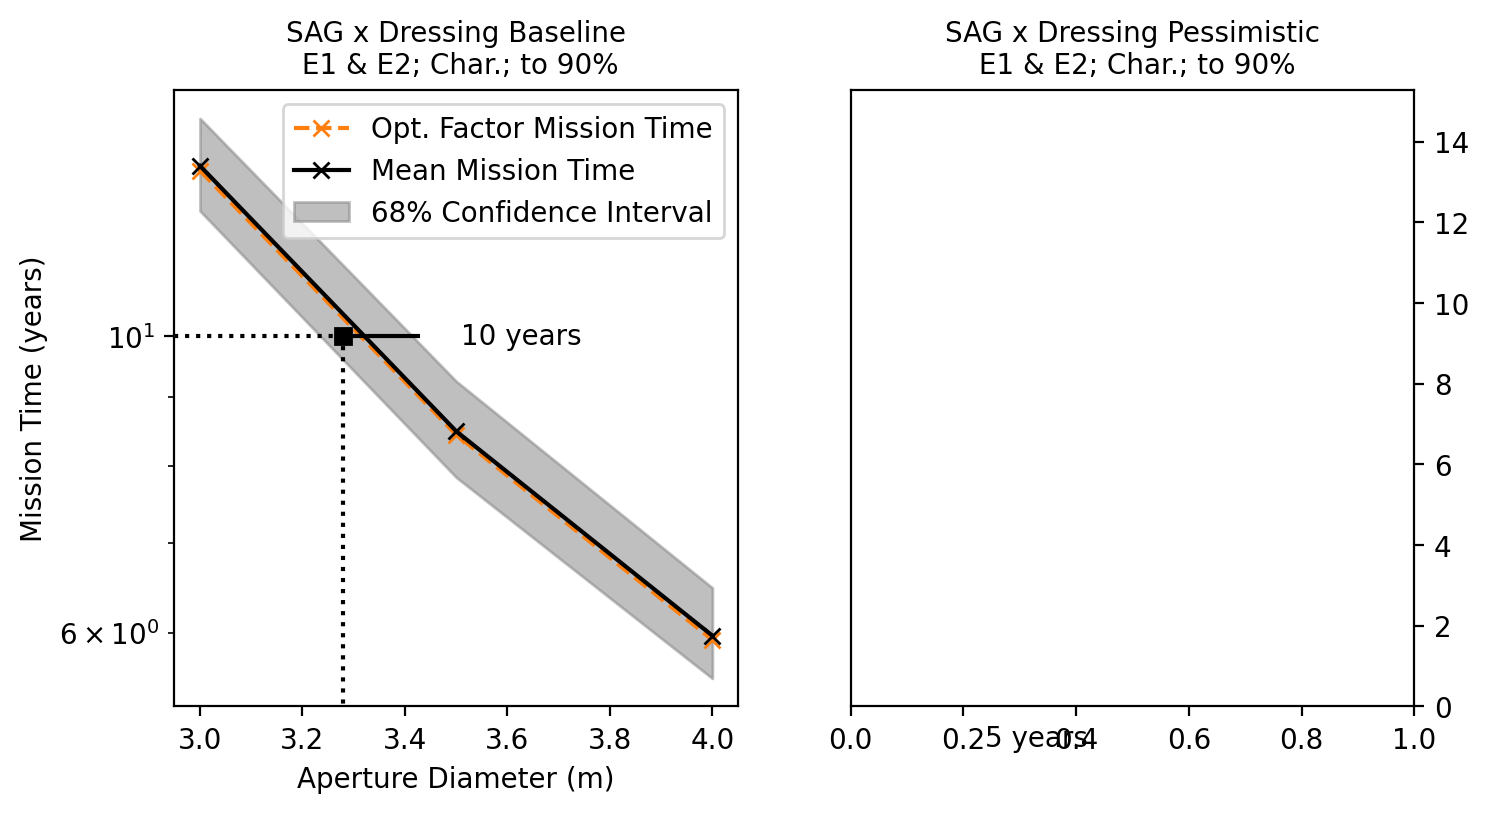

In [15]:
fig, ax = plt.subplots(dpi=200, ncols=2, figsize=(8, 4))

plot_single_opt('/home/kirschkobold/documents/life_internship/LIFEsim_yields/euler_data/20260424_SAGxDressing_baseline/output/opt_e1_e2_f09_char', ax[0])
ax[0].set_title('SAG x Dressing Baseline\n E1 & E2; Char.; to 90%', fontsize=10)

# plot_single_opt('/home/kirschkobold/documents/life_internship/LIFEsim_yields/euler_data/20260424_SAGxDressing_pessimistic/output/opt_e1_e2_f09_char', ax[1], text_vertical=True, legend=False)
ax[1].set_title('SAG x Dressing Pessimistic\n E1 & E2; Char.; to 90%', fontsize=10)

# yaxis of right plot to the right
ax[1].yaxis.set_label_position("right")
ax[1].yaxis.tick_right()

# adjust to common y-axis
ymin = min(ax[0].get_ylim()[0], ax[1].get_ylim()[0])
ymax = max(ax[0].get_ylim()[1], ax[1].get_ylim()[1])
ax[0].set_ylim(ymin, ymax)
ax[1].set_ylim(ymin, ymax)

plt.show()

## 2.2 For single catalog, all optimizations

In [16]:
optimize = {
    'e1_e2_f05_char': 'Exp. 1 & 2; Char.',
    'e1_e2_f09_char': 'Exp. 1 & 2; Char.',
     'e1_e2_f05': 'Exp. 1 & 2; Full',
    'e1_e2_f09': 'Exp. 1 & 2; Full',
    'e1_f05_char': 'Exp. 1; Char.',
            'e1_f09_char': 'Exp. 1; Char.',
}

linestyles = {'e1_f05_char': '-.',
            'e1_e2_f05_char': '-',
            'e1_f09_char': '-.',
            'e1_e2_f09_char': '-',
            'e1_e2_f09': '--',
            'e1_e2_f05': '--'}

colors = {'e1_f05_char': 'gray',
            'e1_e2_f05_char': 'tab:orange',
            'e1_f09_char': 'gray',
            'e1_e2_f09_char': 'tab:orange',
            'e1_e2_f09': 'gray',
            'e1_e2_f05': 'gray'}

z_order = {
    'e1_e2_f05_char': 5,
    'e1_f05_char': 3,
    'e1_e2_f09_char': 5,
    'e1_f09_char': 3,
    'e1_e2_f05': 4,
    'e1_e2_f09': 4
}

In [17]:
diam_catalogs

{'20260424_BrysonxDressing_baseline_minus': {'e1_e2_f05_char':       diameter_mean  lu_diameter  uu_diameter  diameter_opt_factor
  0.5        5.602051     0.489530          NaN             5.629148
  1.0        5.321850     0.387727          NaN             5.341070
  1.5        5.057323     0.301601          NaN             5.069380
  2.0        4.808473     0.231149          NaN             4.814077
  2.5        4.575298     0.176373          NaN             4.575161
  3.0        4.357798     0.137273     0.007786             4.352633
  3.5        4.155974     0.113848     0.061450             4.146492
  4.0        3.969825     0.106098     0.099439             3.956738
  4.5        3.799352     0.114024     0.121752             3.783372
  5.0        3.644554     0.137625     0.128390             3.626393
  5.5        3.505432     0.096866     0.119352             3.485801
  6.0        3.381985     0.068548     0.105984             3.361596
  6.5        3.274214     0.055906     0.1

In [ ]:
def get_diam_catalog(catalogs,
                     base_path):
    diam_catalogs = {}

    pbar = tqdm(catalogs)

    for catalog in pbar:
        pbar.set_description(f"Processing {catalog}")

        source_path = os.path.join(base_path, catalog, 'output/')
        diam_catalogs[catalog] = _get_diams_catalog(source_path)

    return diam_catalogs

In [36]:
cat_name =  '20260424_SAGxDressing_baseline'
base_path="/home/kirschkobold/documents/life_internship/LIFEsim_yields/euler_data/"
source_path = os.path.join(base_path, cat_name, 'output/')
diam_catalogs[cat_name] = _get_diams_catalog(source_path)
diam_catalog = _get_diams_catalog(source_path)

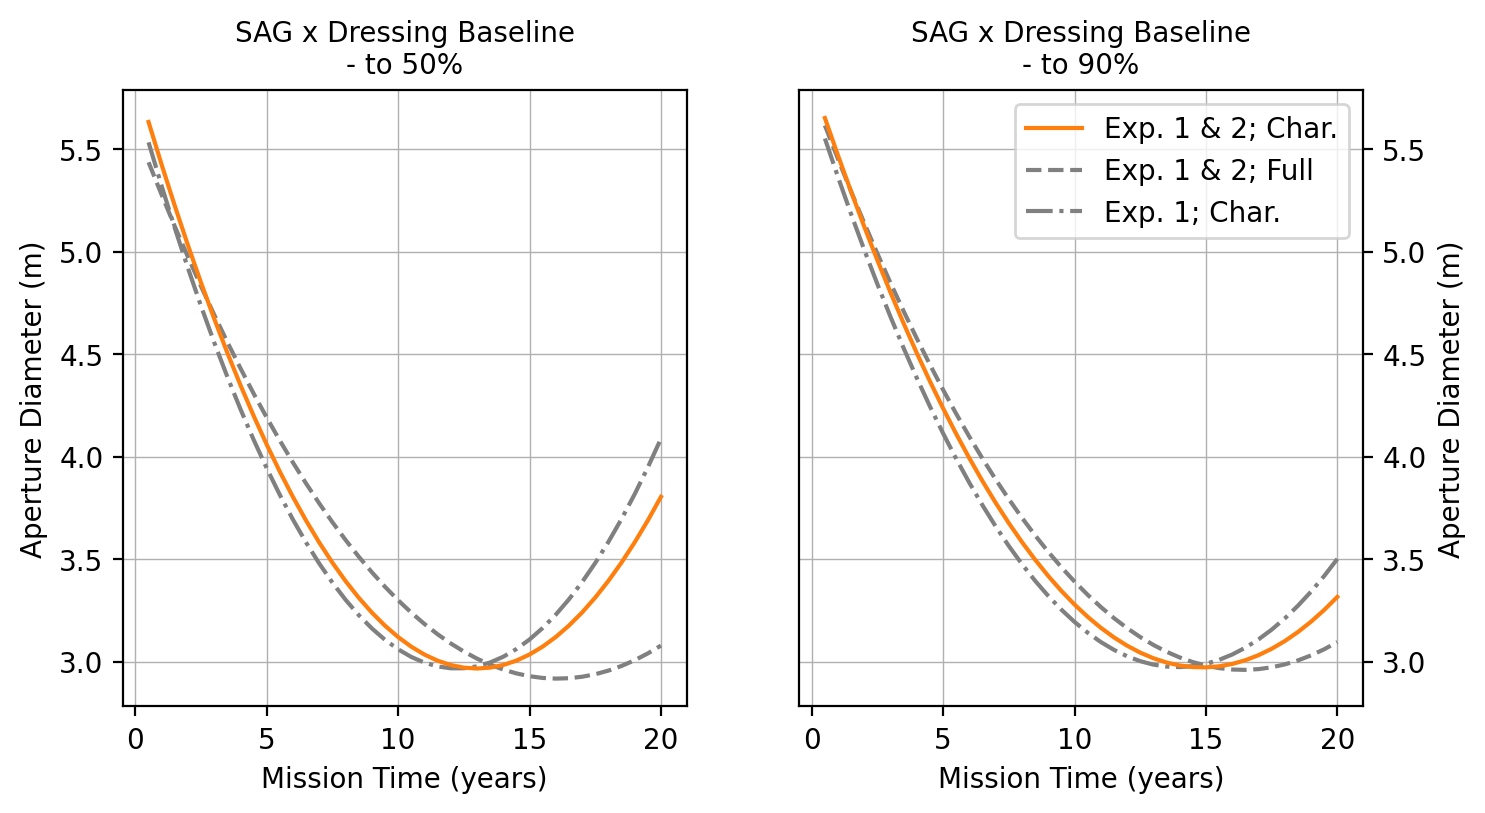

In [35]:
cat_name = '20260424_SAGxDressing_baseline'
diam_time_tables = deepcopy(diam_catalogs[cat_name])

# sort opt_name by mean diameter at 10 years
diam_time_tables = dict(sorted(diam_time_tables.items(), key=lambda item: item[1].loc[2.5, 'diameter_mean']))

fig, ax = plt.subplots(dpi=200, ncols=2, figsize=(8, 4))

for opt in optimize.keys():
    if 'f05' in opt:
        ax[0].plot(diam_time_tables[opt].index, diam_time_tables[opt]['diameter_mean'], label=optimize[opt], color=colors[opt], linestyle=linestyles[opt], zorder=z_order[opt])
    else:
        ax[1].plot(diam_time_tables[opt].index, diam_time_tables[opt]['diameter_mean'], label=optimize[opt], color=colors[opt], linestyle=linestyles[opt], zorder=z_order[opt])


#for opt_name, table in diam_time_tables.items():
#    c = colors.pop(0)
#    plt.plot(table.index, table['diameter_mean'], label=opt_name, color=c)
    # plt.fill_between(table.index,
    #                  table['diameter_mean'] - table['lu_diameter'],
    #                  table['diameter_mean'] + table['uu_diameter'],
    #                  alpha=0.3,
    #                  color=c,)
ax[0].set_xlabel('Mission Time (years)')
ax[0].set_ylabel('Aperture Diameter (m)')

ax[1].set_xlabel('Mission Time (years)')
ax[1].set_ylabel('Aperture Diameter (m)')

ax[0].grid(True, which='both', linestyle='-', linewidth=0.5)
ax[1].grid(True, which='both', linestyle='-', linewidth=0.5)

ax[0].set_title(f'SAG x Dressing Baseline\n- to 50%', fontsize=10)
ax[1].set_title(f'SAG x Dressing Baseline\n- to 90%', fontsize=10)


ax[1].legend()

# yaxis of right plot to the right
ax[1].yaxis.set_label_position("right")
ax[1].yaxis.tick_right()

# adjust to common y-axis
ymin = min(ax[0].get_ylim()[0], ax[1].get_ylim()[0])
ymax = max(ax[0].get_ylim()[1], ax[1].get_ylim()[1])
ax[0].set_ylim(ymin, ymax)
ax[1].set_ylim(ymin, ymax)

plt.show()

In [19]:
from scipy.optimize import curve_fit

# 1. Define the model function: a*x^b + c
def model_func(x, a, b, c):
    return a*x**b

In [20]:
exps = []

initial_guess = [1.0, 1.0, 1.0]
for scen in diam_time_tables.keys():
    try:
        popt, pcov = curve_fit(model_func, list(diam_time_tables[scen].index), diam_time_tables[scen]['diameter_mean'], p0=initial_guess, maxfev=10000)
        exps.append(popt[1])
    except:
        pass

/tmp/ipykernel_1032822/608298883.py:6: OptimizeWarning: Covariance of the parameters could not be estimated
  popt, pcov = curve_fit(model_func, list(diam_time_tables[scen].index), diam_time_tables[scen]['diameter_mean'], p0=initial_guess, maxfev=10000)


In [21]:
1/np.array(exps)

array([-5.81970367, -4.95736476, -5.12021576, -5.25585959, -4.85993189,
       -4.8337924 ,  0.46637105,  0.47250057])

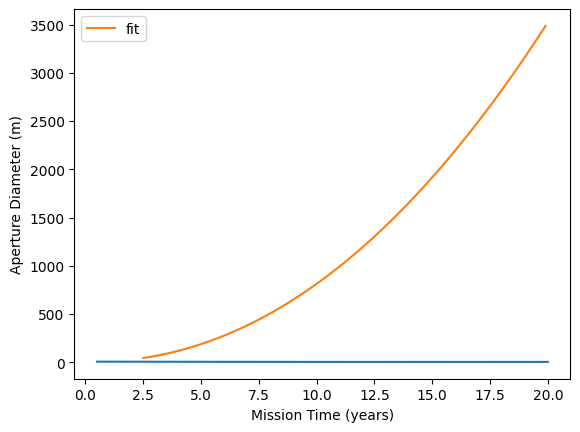

In [22]:
plt.plot(list(diam_time_tables['e1_e2_f09_char'].index), diam_time_tables['e1_e2_f09_char']['diameter_mean'])
x = np.arange(2.5, 20, 0.1)
# plt.plot(x, model_func(x, *[1,  -5,  3]), label='Fit')
plt.plot(x, model_func(x, *popt), label='fit')
# plt.xscale('log')
# plt.yscale('log')

plt.xlabel('Mission Time (years)')
plt.ylabel('Aperture Diameter (m)')

plt.legend()
plt.show()

In [23]:
popt

array([6.21542161, 2.11639957, 1.        ])

In [24]:
diam_time_tables['e1_e2_f09_char']

,diameter_mean,lu_diameter,uu_diameter,diameter_opt_factor
0.5,5.652051,0.554155,NaN,5.640364
1.0,5.468683,0.479632,NaN,5.457110
1.5,5.291814,0.411608,NaN,5.280369
2.0,5.121444,0.350083,NaN,5.110142
2.5,4.957574,0.295057,NaN,4.946429
3.0,4.800203,0.246530,NaN,4.789229
3.5,4.649331,0.204503,NaN,4.638542
4.0,4.504958,0.168975,NaN,4.494369
4.5,4.367085,0.139946,NaN,4.356709
5.0,4.235710,0.117416,0.031214,4.225563


## 2.3 Detection time ratio plot

In [25]:
path = '/home/kirschkobold/documents/life_internship/LIFEsim_yields/euler_data/20260424_SAGxDressing_pessimistic/output/opt_e1_e2_f09_char/'

name = [x for x in path.split('/') if x != ''][-1]
mission_time = pd.read_csv(os.path.join(path, name + '_diameter_mission_time_RAW.csv'), index_col=0)
max_time_table = pd.read_csv(os.path.join(path, name + '_diameter_mission_time.csv'), index_col=0)

In [26]:
mission_time

,mission_time_mean,lu_mission_time,uu_mission_time,mission_time_opt_factor,detection_ratio_mean,lu_detection_ratio,uu_detection_ratio
3.0,2.132797e+09,1.663760e+08,2.049553e+08,2.115433e+09,0.655537,0.061132,0.051113
3.5,1.310189e+09,9.598969e+07,1.115583e+08,1.301122e+09,0.659419,0.055329,0.047931
4.0,8.770250e+08,6.161525e+07,7.166340e+07,8.709682e+08,0.666019,0.053859,0.046198


## 2.4 Final plot, FGK-version

In [42]:
etas = pd.read_csv('/home/kirschkobold/documents/life_internship/LIFEsim_yields/euler_data/eta_summary.csv', index_col=0)

In [43]:
etas

,etas_exp,etas_all,etas_fgk,etas_m
20260424_BrysonxDressing_baseline_minus,0.251711,0.251741,0.221276,0.296155
20260424_BrysonxDressing_baseline_plus,0.325030,0.325461,0.345563,0.296155
20260424_BrysonxDressing_optimistic,0.403684,0.403980,0.345563,0.489149
20260424_BrysonxDressing_pessimistic,0.215429,0.215521,0.221276,0.207129
20260424_SAGxDressing_baseline,0.251802,0.251796,0.221370,0.296155
20260424_SAGxDressing_optimistic,0.576475,0.576627,0.636628,0.489149
20260424_SAGxDressing_pessimistic,0.131868,0.131260,0.079221,0.207129


In [28]:
etas.round(2)

,etas_exp,etas_all,etas_fgk,etas_m
20260424_BrysonxDressing_baseline_minus,0.25,0.25,0.22,0.30
20260424_BrysonxDressing_baseline_plus,0.33,0.33,0.35,0.30
20260424_BrysonxDressing_optimistic,0.40,0.40,0.35,0.49
20260424_BrysonxDressing_pessimistic,0.22,0.22,0.22,0.21
20260424_SAGxDressing_baseline,0.25,0.25,0.22,0.30
20260424_SAGxDressing_optimistic,0.58,0.58,0.64,0.49
20260424_SAGxDressing_pessimistic,0.13,0.13,0.08,0.21


In [29]:
reduce_eta = {'SxD pess': ['20260424_SAGxDressing_pessimistic'],
              'SxD base;\nBxD base-;\nBxD pess': ['20260424_SAGxDressing_baseline', '20260424_BrysonxDressing_baseline_minus', '20260424_BrysonxDressing_pessimistic'],
              'BxD opt;\nBxD base+': ['20260424_BrysonxDressing_optimistic', '20260424_BrysonxDressing_baseline_plus'],
              'SxD opt': ['20260424_SAGxDressing_optimistic'],}

etas_reduced = {}
for key, value in reduce_eta.items():
    etas_reduced[key] = etas.loc[value, 'etas_fgk'].mean()

etas_reduced = pd.DataFrame.from_dict(etas_reduced, orient='index', columns=['etas_fgk'])

In [38]:
etas_reduced

,etas_fgk
SxD pess,0.079221
SxD base;\nBxD base-;\nBxD pess,0.221307
BxD opt;\nBxD base+,0.345563
SxD opt,0.636628


In [30]:
opt = 'e1_e2_f09_char'
mtime = 5.0


def _disentragle_bryson_sag(opt, mtime):
    val_bryson = []
    val_sag = []

    for cat in diam_catalogs.keys():
        try:
            if 'Bryson' in cat:
                val_bryson.append(
                    [etas.loc[cat, 'etas_fgk'], diam_catalogs[cat][opt]['diameter_mean'].loc[mtime]]
                )
            else:
                val_sag.append(
                    [etas.loc[cat, 'etas_fgk'], diam_catalogs[cat][opt]['diameter_mean'].loc[mtime]]
                )
        except:
            pass

    val_bryson = np.array(val_bryson)
    val_bryson = val_bryson[val_bryson[:, 0].argsort()]
    val_sag = np.array(val_sag)
    val_sag = val_sag[val_sag[:, 0].argsort()]

    return val_bryson, val_sag

In [41]:
val_bryson

array([[0.22127636, 3.90917648],
       [0.22127636, 4.01793656],
       [0.34556271, 3.5289832 ],
       [0.34556271, 3.49310783]])

In [ ]:
cat_names = {'20260424_SAGxDressing_optimistic': 'SxD opt.',
 '20260424_SAGxDressing_baseline': 'SxD base.',
 '20260424_BrysonxDressing_baseline_minus': 'BxD base-',
 '20260424_BrysonxDressing_baseline_plus': 'BxD base+',
 '20260424_BrysonxDressing_optimistic': 'BxD opt.',
 '20260424_SAGxDressing_pessimistic': 'SxD pess.',
 '20260424_BrysonxDressing_pessimistic': 'BxD pess.'}

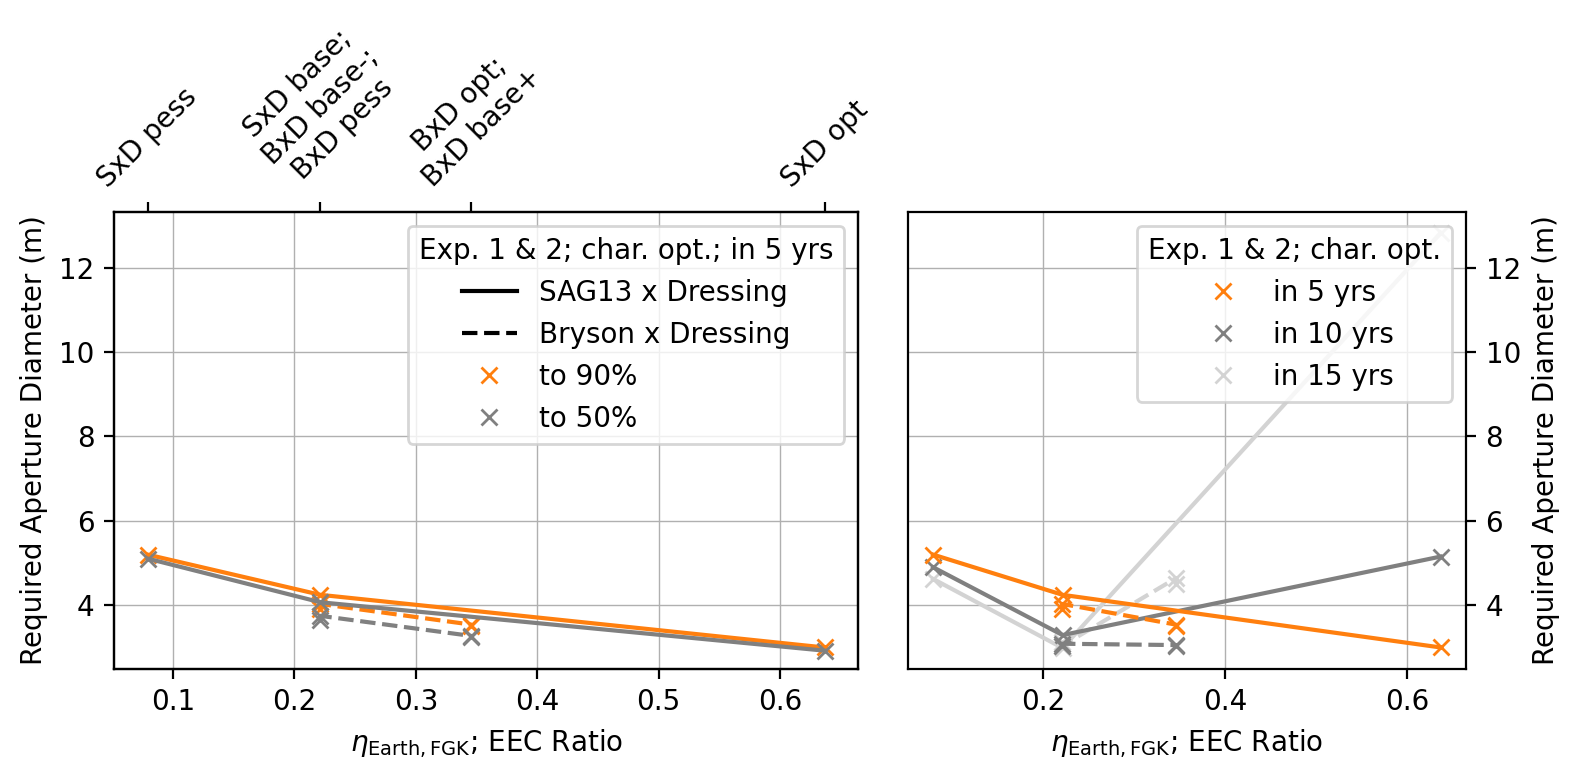

In [39]:
fig, ax = plt.subplots(dpi=200, ncols=2, figsize=(8, 4), gridspec_kw={'width_ratios': [4, 3]})

val_bryson, val_sag = _disentragle_bryson_sag(opt='e1_e2_f09_char', mtime=5.0)

ax[0].plot(val_sag[:, 0], val_sag[:, 1], marker='x', linestyle='-', label='SxD', color='tab:orange')
ax[0].plot(val_bryson[:, 0], val_bryson[:, 1], marker='x', linestyle='--', label='BxD', color='tab:orange')

val_bryson, val_sag = _disentragle_bryson_sag(opt='e1_e2_f05_char', mtime=5.0)

ax[0].plot(val_sag[:, 0], val_sag[:, 1], marker='x', linestyle='-', label='SxD', color='gray')
ax[0].plot(val_bryson[:, 0], val_bryson[:, 1], marker='x', linestyle='--', label='BxD', color='gray')

ax2 = ax[0].twiny()
ax2.set_xticks([])

# 4. Define where you want the markers and what they are called
# Let's say "Mask 1" corresponds to a diameter of 3.0m, and "Mask 2" to 4.5m
marker_labels = etas_reduced.index.to_list()
marker_positions = etas_reduced['etas_fgk'].to_list()

# 3. Add the repelled labels to the second axis
ax2.set_xticks(marker_positions)
ax2.set_xticklabels(marker_labels, rotation=45)

# Rotate and align so the start of the text is near the tick
#plt.setp(ax2.get_xticklabels(), rotation=45, ha='left')

# 5. Configure the second axis
# CRITICAL: Ensure ax2 views the same data range as ax1 so the positions align
ax2.set_xlim(ax[0].get_xlim())

# create custom legend
# black solid line: SAG13 x Dressing
# black dashed line: Bryson x Dressing
# orange markers: to 90%
# gray markers: to 50%

handles = [
    plt.Line2D([0], [0], color='k', linestyle='-', label='SAG13 x Dressing'),
    plt.Line2D([0], [0], color='k', linestyle='--', label='Bryson x Dressing'),
    plt.Line2D([0], [0], marker='x', color='tab:orange', linestyle='', label='to 90%'),
    plt.Line2D([0], [0], marker='x', color='gray', linestyle='', label='to 50%'),
]
ax[0].legend(handles=handles, loc='upper right', title='Exp. 1 & 2; char. opt.; in 5 yrs')

ax[0].set_ylabel('Required Aperture Diameter (m)')
ax[0].set_xlabel(r'$\eta_\mathrm{Earth, FGK}$; EEC Ratio')

ax[0].grid(True, which='both', linestyle='-', linewidth=0.5)

val_bryson, val_sag = _disentragle_bryson_sag(opt='e1_e2_f09_char', mtime=15.0)

ax[1].plot(val_sag[:, 0], val_sag[:, 1], marker='x', linestyle='-', label='SxD', color='lightgray')
ax[1].plot(val_bryson[:, 0], val_bryson[:, 1], marker='x', linestyle='--', label='BxD', color='lightgray')

val_bryson, val_sag = _disentragle_bryson_sag(opt='e1_e2_f09_char', mtime=10.0)

ax[1].plot(val_sag[:, 0], val_sag[:, 1], marker='x', linestyle='-', label='SxD', color='gray')
ax[1].plot(val_bryson[:, 0], val_bryson[:, 1], marker='x', linestyle='--', label='BxD', color='gray')

val_bryson, val_sag = _disentragle_bryson_sag(opt='e1_e2_f09_char', mtime=5.0)

ax[1].plot(val_sag[:, 0], val_sag[:, 1], marker='x', linestyle='-', label='SxD', color='tab:orange')
ax[1].plot(val_bryson[:, 0], val_bryson[:, 1], marker='x', linestyle='--', label='BxD', color='tab:orange')

# yaxis of right plot to the right
ax[1].yaxis.set_label_position("right")
ax[1].yaxis.tick_right()

ax[1].grid(True, which='both', linestyle='-', linewidth=0.5)

ax[1].set_ylabel('Required Aperture Diameter (m)')
ax[1].set_xlabel(r'$\eta_\mathrm{Earth, FGK}$; EEC Ratio')

handles = [
    plt.Line2D([0], [0], marker='x', color='tab:orange', linestyle='', label='in 5 yrs'),
    plt.Line2D([0], [0], marker='x', color='gray', linestyle='', label='in 10 yrs'),
    plt.Line2D([0], [0], marker='x', color='lightgray', linestyle='', label='in 15 yrs'),
]
ax[1].legend(handles=handles, loc='upper right', title='Exp. 1 & 2; char. opt.')

# adjust to common y-axis
ymin = min(ax[0].get_ylim()[0], ax[1].get_ylim()[0])
ymax = max(ax[0].get_ylim()[1], ax[1].get_ylim()[1])
ax[0].set_ylim(ymin, ymax)
ax[1].set_ylim(ymin, ymax)

fig.tight_layout()

plt.show()

# 2.5 Final Plot, all version

In [ ]:
val_bryson, val_sag = _disentragle_bryson_sag(opt='e1_e2_f09_char', mtime=10.0)

In [ ]:
print(val_bryson)

[[0.22127636 3.01534232]
 [0.22127636 3.07362818]
 [0.34556271 3.04232275]
 [0.34556271 3.01261365]]


In [ ]:
reduce_eta = {'SxD pess': ['20260424_SAGxDressing_pessimistic'],
              'SxD base;\nBxD base-;\nBxD pess': ['20260424_SAGxDressing_baseline', '20260424_BrysonxDressing_baseline_minus', '20260424_BrysonxDressing_pessimistic'],
              'BxD opt;\nBxD base+': ['20260424_BrysonxDressing_optimistic', '20260424_BrysonxDressing_baseline_plus'],
              'SxD opt': ['20260424_SAGxDressing_optimistic'],}

etas_reduced = {}
for key, value in reduce_eta.items():
    etas_reduced[key] = etas.loc[value, 'etas_m'].mean()

etas_reduced = pd.DataFrame.from_dict(etas_reduced, orient='index', columns=['etas_m'])

def _disentragle_bryson_sag(opt, mtime):
    val_bryson = []
    val_sag = []

    for cat in diam_catalogs.keys():
        try:
            if 'Bryson' in cat:
                val_bryson.append(
                    [etas.loc[cat, 'etas_m'], diam_catalogs[cat][opt]['diameter_mean'].loc[mtime]]
                )
            else:
                val_sag.append(
                    [etas.loc[cat, 'etas_m'], diam_catalogs[cat][opt]['diameter_mean'].loc[mtime]]
                )
        except:
            pass

    val_bryson = np.array(val_bryson)
    val_bryson = val_bryson[val_bryson[:, 0].argsort()]
    val_sag = np.array(val_sag)
    val_sag = val_sag[val_sag[:, 0].argsort()]

    return val_bryson, val_sag

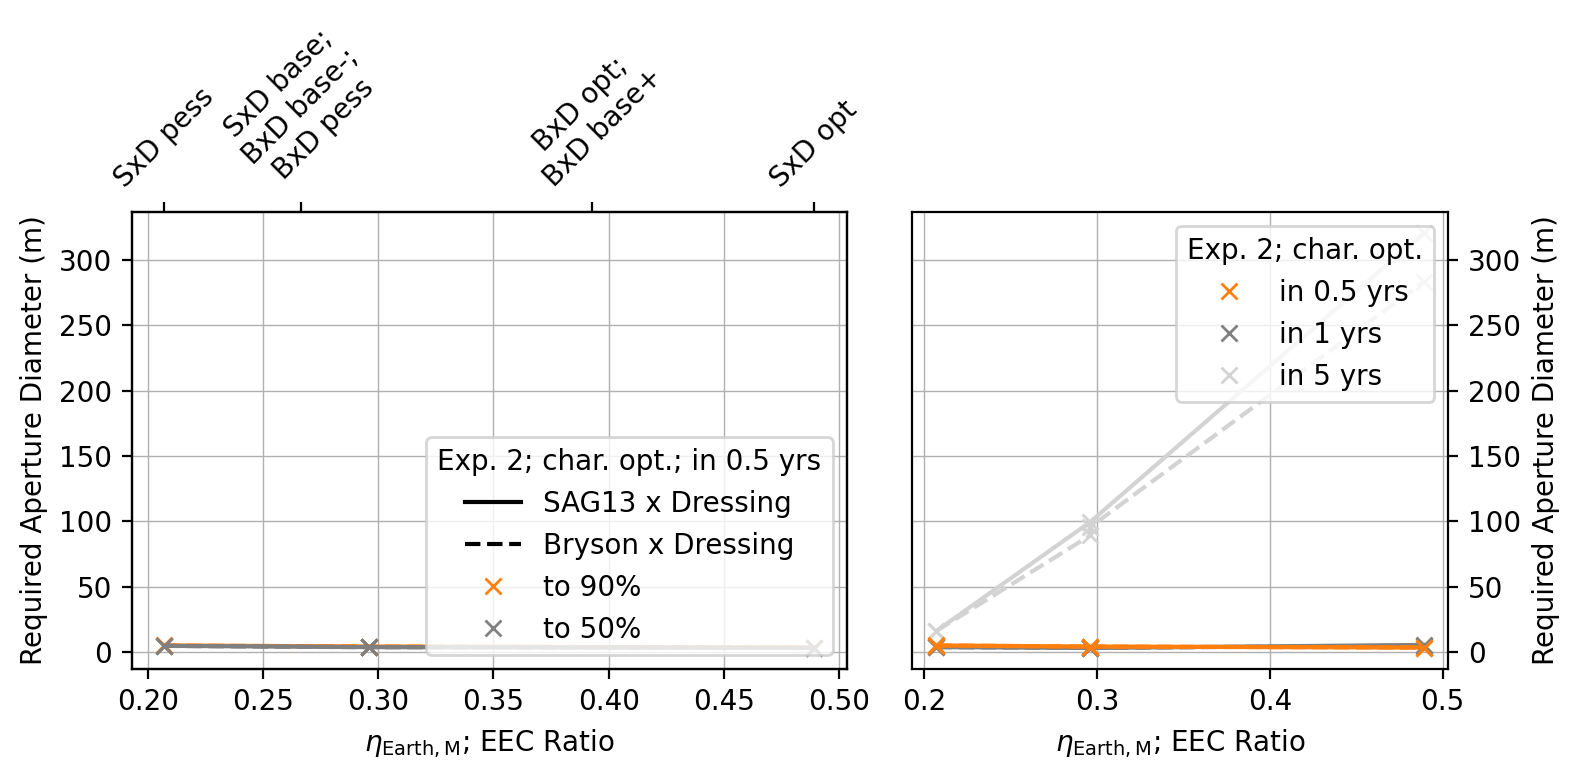

In [ ]:
fig, ax = plt.subplots(dpi=200, ncols=2, figsize=(8, 4), gridspec_kw={'width_ratios': [4, 3]})

val_bryson, val_sag = _disentragle_bryson_sag(opt='e2_f09_char', mtime=0.5)

ax[0].plot(val_sag[:, 0], val_sag[:, 1], marker='x', linestyle='-', label='SxD', color='tab:orange')
ax[0].plot(val_bryson[:, 0], val_bryson[:, 1], marker='x', linestyle='--', label='BxD', color='tab:orange')

val_bryson, val_sag = _disentragle_bryson_sag(opt='e2_f05_char', mtime=0.5)

ax[0].plot(val_sag[:, 0], val_sag[:, 1], marker='x', linestyle='-', label='SxD', color='gray')
ax[0].plot(val_bryson[:, 0], val_bryson[:, 1], marker='x', linestyle='--', label='BxD', color='gray')

ax2 = ax[0].twiny()
ax2.set_xticks([])

# 4. Define where you want the markers and what they are called
# Let's say "Mask 1" corresponds to a diameter of 3.0m, and "Mask 2" to 4.5m
marker_labels = etas_reduced.index.to_list()
marker_positions = etas_reduced['etas_m'].to_list()

# 3. Add the repelled labels to the second axis
ax2.set_xticks(marker_positions)
ax2.set_xticklabels(marker_labels, rotation=45)

# Rotate and align so the start of the text is near the tick
#plt.setp(ax2.get_xticklabels(), rotation=45, ha='left')

# 5. Configure the second axis
# CRITICAL: Ensure ax2 views the same data range as ax1 so the positions align
ax2.set_xlim(ax[0].get_xlim())

# create custom legend
# black solid line: SAG13 x Dressing
# black dashed line: Bryson x Dressing
# orange markers: to 90%
# gray markers: to 50%

handles = [
    plt.Line2D([0], [0], color='k', linestyle='-', label='SAG13 x Dressing'),
    plt.Line2D([0], [0], color='k', linestyle='--', label='Bryson x Dressing'),
    plt.Line2D([0], [0], marker='x', color='tab:orange', linestyle='', label='to 90%'),
    plt.Line2D([0], [0], marker='x', color='gray', linestyle='', label='to 50%'),
]
ax[0].legend(handles=handles, loc='lower right', title='Exp. 2; char. opt.; in 0.5 yrs')

ax[0].set_ylabel('Required Aperture Diameter (m)')
ax[0].set_xlabel(r'$\eta_\mathrm{Earth, M}$; EEC Ratio')

ax[0].grid(True, which='both', linestyle='-', linewidth=0.5)

val_bryson, val_sag = _disentragle_bryson_sag(opt='e2_f09_char', mtime=5.0)

ax[1].plot(val_sag[:, 0], val_sag[:, 1], marker='x', linestyle='-', label='SxD', color='lightgray')
ax[1].plot(val_bryson[:, 0], val_bryson[:, 1], marker='x', linestyle='--', label='BxD', color='lightgray')

val_bryson, val_sag = _disentragle_bryson_sag(opt='e2_f09_char', mtime=1.0)

ax[1].plot(val_sag[:, 0], val_sag[:, 1], marker='x', linestyle='-', label='SxD', color='gray')
ax[1].plot(val_bryson[:, 0], val_bryson[:, 1], marker='x', linestyle='--', label='BxD', color='gray')

val_bryson, val_sag = _disentragle_bryson_sag(opt='e2_f09_char', mtime=0.5)

ax[1].plot(val_sag[:, 0], val_sag[:, 1], marker='x', linestyle='-', label='SxD', color='tab:orange')
ax[1].plot(val_bryson[:, 0], val_bryson[:, 1], marker='x', linestyle='--', label='BxD', color='tab:orange')

# yaxis of right plot to the right
ax[1].yaxis.set_label_position("right")
ax[1].yaxis.tick_right()

ax[1].grid(True, which='both', linestyle='-', linewidth=0.5)

ax[1].set_ylabel('Required Aperture Diameter (m)')
ax[1].set_xlabel(r'$\eta_\mathrm{Earth, M}$; EEC Ratio')

handles = [
    plt.Line2D([0], [0], marker='x', color='tab:orange', linestyle='', label='in 0.5 yrs'),
    plt.Line2D([0], [0], marker='x', color='gray', linestyle='', label='in 1 yrs'),
    plt.Line2D([0], [0], marker='x', color='lightgray', linestyle='', label='in 5 yrs'),
]
ax[1].legend(handles=handles, loc='upper right', title='Exp. 2; char. opt.')

# adjust to common y-axis
ymin = min(ax[0].get_ylim()[0], ax[1].get_ylim()[0])
ymax = max(ax[0].get_ylim()[1], ax[1].get_ylim()[1])
ax[0].set_ylim(ymin, ymax)
ax[1].set_ylim(ymin, ymax)

fig.tight_layout()

plt.show()

In [ ]:
reduce_eta = {'SxD pess': ['20260424_SAGxDressing_pessimistic'],
              'SxD base; BxD base-': ['20260424_SAGxDressing_baseline', '20260424_BrysonxDressing_baseline_minus'],
              'BxD pess': ['20260424_BrysonxDressing_pessimistic'],
              'BxD opt': ['20260424_BrysonxDressing_optimistic'],
              'BxD base+': ['20260424_BrysonxDressing_baseline_plus'],
              'SxD opt': ['20260424_SAGxDressing_optimistic'],}

etas_reduced = {}
for key, value in reduce_eta.items():
    etas_reduced[key] = etas.loc[value, 'etas_all'].mean()

etas_reduced = pd.DataFrame.from_dict(etas_reduced, orient='index', columns=['etas_all'])

In [ ]:
opt = 'e1_e2_f09_char'
mtime = 5.0


def _disentragle_bryson_sag(opt, mtime):
    val_bryson = []
    val_sag = []

    for cat in diam_catalogs.keys():
        try:
            if 'Bryson' in cat:
                val_bryson.append(
                    [etas.loc[cat, 'etas_all'], diam_catalogs[cat][opt]['diameter_mean'].loc[mtime]]
                )
            else:
                val_sag.append(
                    [etas.loc[cat, 'etas_all'], diam_catalogs[cat][opt]['diameter_mean'].loc[mtime]]
                )
        except:
            pass

    val_bryson = np.array(val_bryson)
    val_bryson = val_bryson[val_bryson[:, 0].argsort()]
    val_sag = np.array(val_sag)
    val_sag = val_sag[val_sag[:, 0].argsort()]

    return val_bryson, val_sag

In [ ]:
cat_names = {'20260424_SAGxDressing_optimistic': 'SxD opt.',
 '20260424_SAGxDressing_baseline': 'SxD base.',
 '20260424_BrysonxDressing_baseline_minus': 'BxD base-',
 '20260424_BrysonxDressing_baseline_plus': 'BxD base+',
 '20260424_BrysonxDressing_optimistic': 'BxD opt.',
 '20260424_SAGxDressing_pessimistic': 'SxD pess.',
 '20260424_BrysonxDressing_pessimistic': 'BxD pess.'}

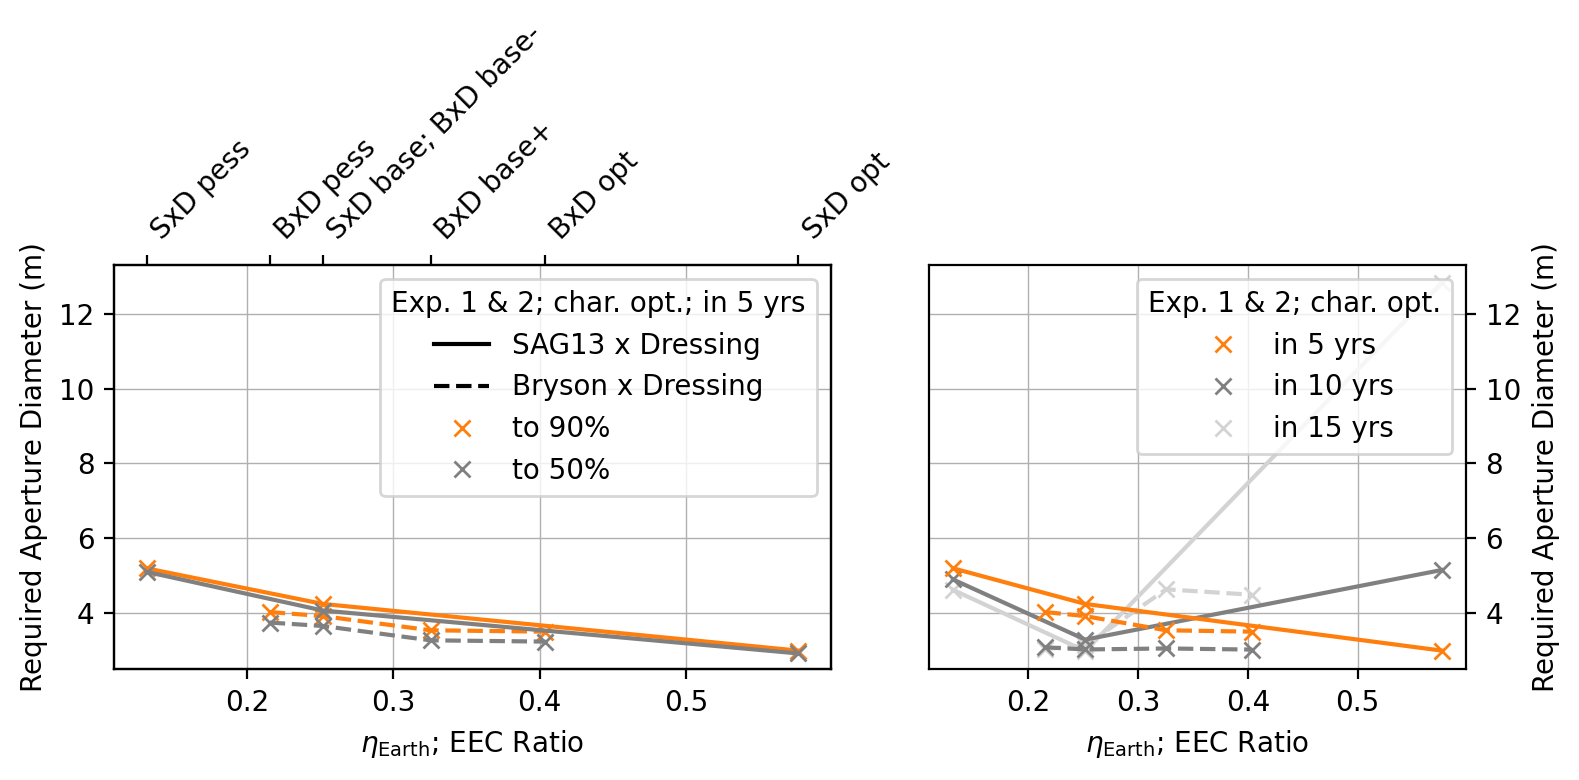

In [ ]:
fig, ax = plt.subplots(dpi=200, ncols=2, figsize=(8, 4), gridspec_kw={'width_ratios': [4, 3]})

val_bryson, val_sag = _disentragle_bryson_sag(opt='e1_e2_f09_char', mtime=5.0)

ax[0].plot(val_sag[:, 0], val_sag[:, 1], marker='x', linestyle='-', label='SxD', color='tab:orange')
ax[0].plot(val_bryson[:, 0], val_bryson[:, 1], marker='x', linestyle='--', label='BxD', color='tab:orange')

val_bryson, val_sag = _disentragle_bryson_sag(opt='e1_e2_f05_char', mtime=5.0)

ax[0].plot(val_sag[:, 0], val_sag[:, 1], marker='x', linestyle='-', label='SxD', color='gray')
ax[0].plot(val_bryson[:, 0], val_bryson[:, 1], marker='x', linestyle='--', label='BxD', color='gray')

ax2 = ax[0].twiny()
ax2.set_xticks([])

# 4. Define where you want the markers and what they are called
# Let's say "Mask 1" corresponds to a diameter of 3.0m, and "Mask 2" to 4.5m
marker_labels = etas_reduced.index.to_list()
marker_positions = etas_reduced['etas_all'].to_list()

# 3. Add the repelled labels to the second axis
ax2.set_xticks(marker_positions)
ax2.set_xticklabels(marker_labels)

# Rotate and align so the start of the text is near the tick
plt.setp(ax2.get_xticklabels(), rotation=45, ha='left')

# 5. Configure the second axis
# CRITICAL: Ensure ax2 views the same data range as ax1 so the positions align
ax2.set_xlim(ax[0].get_xlim())

ax2.grid(False)

# create custom legend
# black solid line: SAG13 x Dressing
# black dashed line: Bryson x Dressing
# orange markers: to 90%
# gray markers: to 50%

handles = [
    plt.Line2D([0], [0], color='k', linestyle='-', label='SAG13 x Dressing'),
    plt.Line2D([0], [0], color='k', linestyle='--', label='Bryson x Dressing'),
    plt.Line2D([0], [0], marker='x', color='tab:orange', linestyle='', label='to 90%'),
    plt.Line2D([0], [0], marker='x', color='gray', linestyle='', label='to 50%'),
]
ax[0].legend(handles=handles, loc='upper right', title='Exp. 1 & 2; char. opt.; in 5 yrs')

ax[0].set_ylabel('Required Aperture Diameter (m)')
ax[0].set_xlabel(r'$\eta_\mathrm{Earth}$; EEC Ratio')

ax[0].grid(True, which='both', linestyle='-', linewidth=0.5)

val_bryson, val_sag = _disentragle_bryson_sag(opt='e1_e2_f09_char', mtime=15.0)

ax[1].plot(val_sag[:, 0], val_sag[:, 1], marker='x', linestyle='-', label='SxD', color='lightgray')
ax[1].plot(val_bryson[:, 0], val_bryson[:, 1], marker='x', linestyle='--', label='BxD', color='lightgray')

val_bryson, val_sag = _disentragle_bryson_sag(opt='e1_e2_f09_char', mtime=10.0)

ax[1].plot(val_sag[:, 0], val_sag[:, 1], marker='x', linestyle='-', label='SxD', color='gray')
ax[1].plot(val_bryson[:, 0], val_bryson[:, 1], marker='x', linestyle='--', label='BxD', color='gray')

val_bryson, val_sag = _disentragle_bryson_sag(opt='e1_e2_f09_char', mtime=5.0)

ax[1].plot(val_sag[:, 0], val_sag[:, 1], marker='x', linestyle='-', label='SxD', color='tab:orange')
ax[1].plot(val_bryson[:, 0], val_bryson[:, 1], marker='x', linestyle='--', label='BxD', color='tab:orange')

# yaxis of right plot to the right
ax[1].yaxis.set_label_position("right")
ax[1].yaxis.tick_right()

ax[1].grid(True, which='both', linestyle='-', linewidth=0.5)

ax[1].set_ylabel('Required Aperture Diameter (m)')
ax[1].set_xlabel(r'$\eta_\mathrm{Earth}$; EEC Ratio')

handles = [
    plt.Line2D([0], [0], marker='x', color='tab:orange', linestyle='', label='in 5 yrs'),
    plt.Line2D([0], [0], marker='x', color='gray', linestyle='', label='in 10 yrs'),
    plt.Line2D([0], [0], marker='x', color='lightgray', linestyle='', label='in 15 yrs'),
]
ax[1].legend(handles=handles, loc='upper right', title='Exp. 1 & 2; char. opt.')

# adjust to common y-axis
ymin = min(ax[0].get_ylim()[0], ax[1].get_ylim()[0])
ymax = max(ax[0].get_ylim()[1], ax[1].get_ylim()[1])
ax[0].set_ylim(ymin, ymax)
ax[1].set_ylim(ymin, ymax)

fig.tight_layout()

plt.show()

In [ ]:
val_bryson, val_sag = _disentragle_bryson_sag(opt='e1_e2_f09_char', mtime=5.0)

val_tot = np.append(val_bryson, val_sag, axis=0)

<>:16: SyntaxWarning: invalid escape sequence '\e'
<>:16: SyntaxWarning: invalid escape sequence '\e'
/tmp/ipykernel_869407/1324207543.py:16: SyntaxWarning: invalid escape sequence '\e'
  plt.xlabel('$\eta_\mathrm{Earth, FGK}$; EEC Ratio')
/tmp/ipykernel_869407/1324207543.py:1: OptimizeWarning: Covariance of the parameters could not be estimated
  popt_tot, _ = curve_fit(model_func, val_tot[:, 0], val_tot[:, 1], p0=initial_guess, maxfev=10000)
/tmp/ipykernel_869407/1324207543.py:2: OptimizeWarning: Covariance of the parameters could not be estimated
  popt_sag, _ = curve_fit(model_func, val_sag[:, 0], val_sag[:, 1], p0=initial_guess, maxfev=10000)
/tmp/ipykernel_869407/1324207543.py:3: OptimizeWarning: Covariance of the parameters could not be estimated
  popt_bry, _ = curve_fit(model_func, val_bryson[:, 0], val_bryson[:, 1], p0=initial_guess, maxfev=10000)


[]

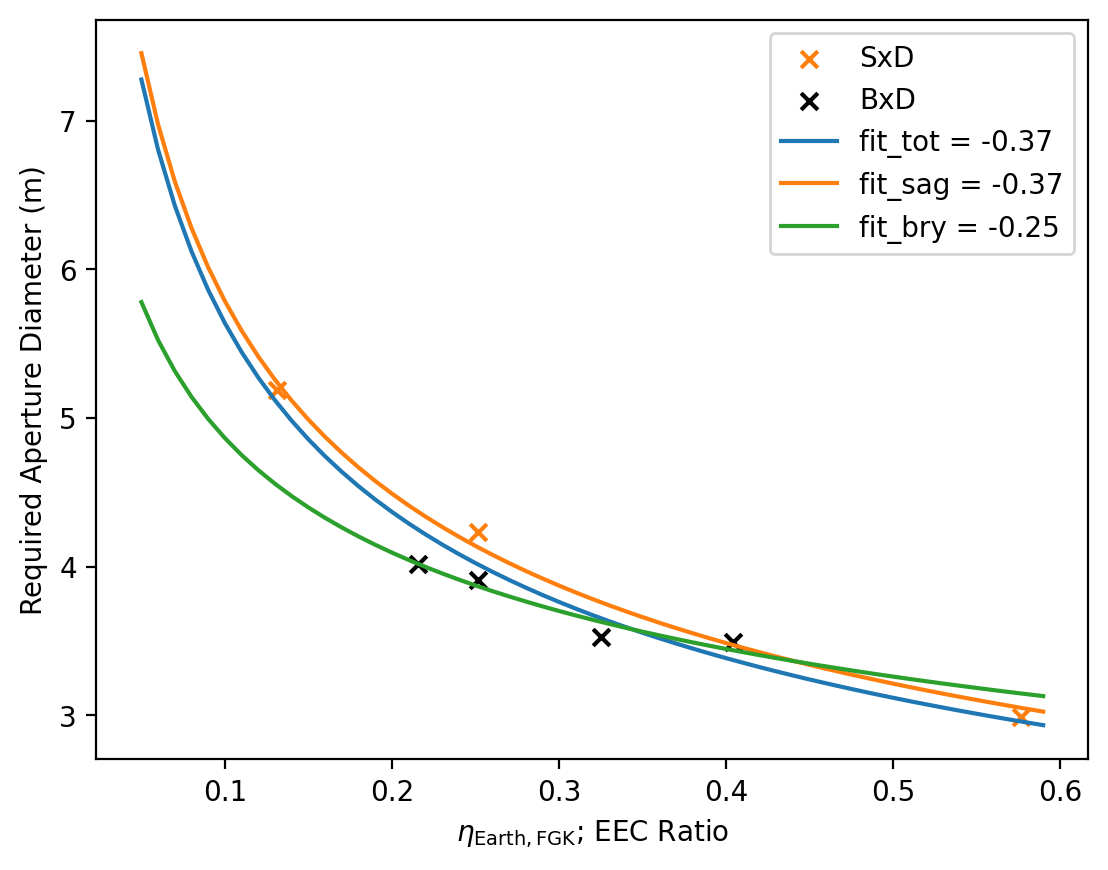

In [ ]:
popt_tot, _ = curve_fit(model_func, val_tot[:, 0], val_tot[:, 1], p0=initial_guess, maxfev=10000)
popt_sag, _ = curve_fit(model_func, val_sag[:, 0], val_sag[:, 1], p0=initial_guess, maxfev=10000)
popt_bry, _ = curve_fit(model_func, val_bryson[:, 0], val_bryson[:, 1], p0=initial_guess, maxfev=10000)

fig, ax = plt.subplots(dpi=200)

plt.scatter(val_sag[:, 0], val_sag[:, 1], marker='x', label='SxD', color='tab:orange')
plt.scatter(val_bryson[:, 0], val_bryson[:, 1], marker='x', label='BxD', color='k')

x = np.arange(0.05, 0.6, 0.01)
# plt.plot(x, model_func(x, *[1,  -5,  3]), label='Fit')
plt.plot(x, model_func(x, *popt_tot), label='fit_tot = ' + str(round(popt_tot[1], 2)))
plt.plot(x, model_func(x, *popt_sag), label='fit_sag = ' + str(round(popt_sag[1], 2)))
plt.plot(x, model_func(x, *popt_bry), label='fit_bry = ' + str(round(popt_bry[1], 2)))

plt.xlabel('$\eta_\mathrm{Earth, FGK}$; EEC Ratio')
plt.ylabel('Required Aperture Diameter (m)')

plt.legend()
plt.plot()

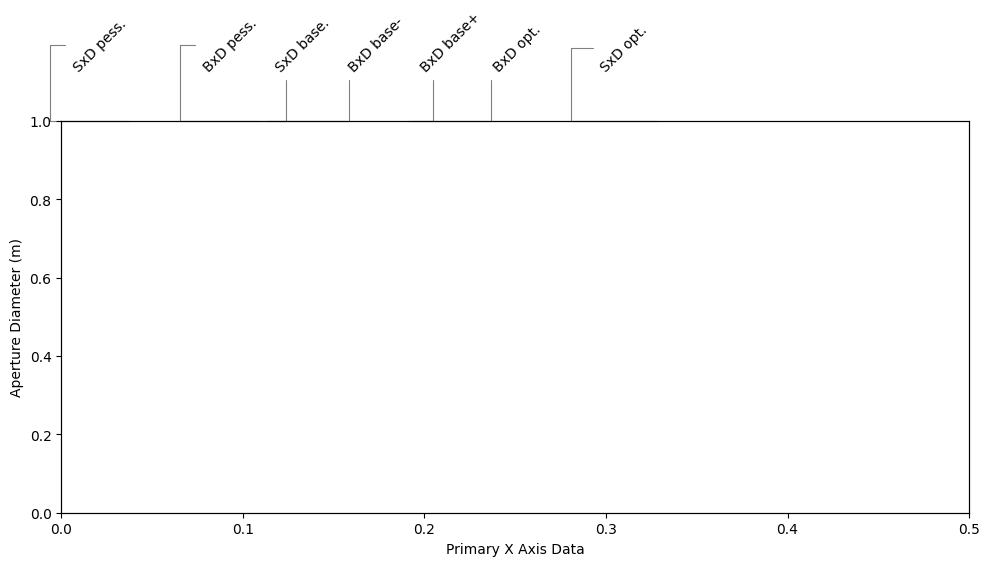

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

def add_top_repelled_labels(ax, x_values, labels, min_spacing=0.8):
    """
    Adds labels to the top of a plot that spread out horizontally
    to avoid overlap, connecting to the x-positions with lines.
    """
    # 1. Sort data by x-position
    sorted_pairs = sorted(zip(x_values, labels))
    x_data_pts, texts = zip(*sorted_pairs)

    # 2. Calculate new horizontal text positions
    x_text_pos = list(x_data_pts)
    for i in range(1, len(x_text_pos)):
        # If the gap between labels is too small, push the right one further
        if x_text_pos[i] - x_text_pos[i-1] < min_spacing:
            x_text_pos[i] = x_text_pos[i-1] + min_spacing

    # Center the label group to minimize line slant
    shift = np.mean(x_text_pos) - np.mean(x_data_pts)
    x_text_pos = [x - shift for x in x_text_pos]

    # 3. Plot the annotations
    # transform: x in "Data" coords, y in "Axes" coords (0=bottom, 1=top)
    transform = ax.get_xaxis_transform()

    for x_data, x_txt, text in zip(x_data_pts, x_text_pos, texts):
        ax.annotate(
            text,
            xy=(x_data, 1.0),             # Point on the top axis line
            xytext=(x_txt, 1.12),         # Text positioned above the axis
            xycoords=transform,
            textcoords=transform,
            rotation=45,                  # Your requested 45-degree angle
            ha='left',                    # Alignment for rotated text
            va='bottom',
            arrowprops=dict(
                arrowstyle="-",
                # 'angle=90' ensures a vertical step, preventing the ValueError
                connectionstyle="bar,fraction=0.2,angle=90",
                color="black",
                linewidth=0.8,
                alpha=0.5
            )
        )

# --- YOUR DATA ---
# Since these were y-values before, I'm treating them as X-positions now
labels = ['SxD opt.', 'SxD base.', 'BxD base-', 'BxD base+', 'BxD opt.', 'SxD pess.', 'BxD pess.']
positions = [0.33015, 0.11134, 0.11227, 0.18900, 0.19144, 0.03962, 0.11124]

# --- PLOTTING ---
fig, ax1 = plt.subplots(figsize=(10, 6))

# Main plot (adjust limits based on your actual data range)
ax1.set_xlim(0, 0.5)
ax1.set_xlabel("Primary X Axis Data")
ax1.set_ylabel("Aperture Diameter (m)")

# Create the top axis
ax2 = ax1.twiny()
ax2.set_xlim(ax1.get_xlim()) # Ensure scales match
ax2.set_xticks([])           # Hide default ticks on top

# Apply the repulsion (adjust min_spacing based on your X-scale)
# On a scale of 0 to 0.5, a spacing of 0.04 is usually good for text
add_top_repelled_labels(ax2, positions, labels, min_spacing=0.04)

# Adjust layout to make room for the top labels
plt.tight_layout()
# Manually push the top margin down to accommodate the rotated text
plt.subplots_adjust(top=0.75)

plt.show()

In [ ]:
catalogs = ['20260424_SAGxDressing_optimistic',
            '20260424_SAGxDressing_baseline',
            '20260424_BrysonxDressing_baseline_minus',
            '20260424_BrysonxDressing_baseline_plus',
            '20260424_BrysonxDressing_optimistic',
            '20260424_SAGxDressing_pessimistic',
            '20260424_BrysonxDressing_pessimistic']

diam_catalogs = {}
etas_all = {}
etas_exp = {}
etas_fgk = {}
etas_m = {}
for catalog in catalogs:
    source_path = f'/home/kirschkobold/documents/life_internship/LIFEsim_yields/euler_data/{catalog}/output/'
    diam_catalogs[catalog] = _get_diams_catalog(source_path)

    catalog_path = f'/home/kirschkobold/documents/life_internship/LIFEsim_yields/euler_data/{catalog}/output/ap_merged/diam_3_0/sweep_diam_3_0_catalog.hdf5'
    eta_all, eta_exp, eta_fgk, eta_m = _get_eff_eta(catalog_path)
    etas_all[catalog] = eta_all
    etas_exp[catalog] = eta_exp
    etas_m[catalog] = eta_m
    etas_fgk[catalog] = eta_fgk

In [ ]:
# Combine into a single DataFrame
etas = pd.DataFrame({
    'etas_exp': etas_exp,
    'etas_all': etas_all,
    'etas_fgk': etas_fgk,
    'etas_m': etas_m
})

# Optional: Reset the index if you want the names as a regular column
# etas = etas.reset_index().rename(columns={'index': 'scenario'})

etas.to_csv('/home/kirschkobold/documents/life_internship/LIFEsim_yields/eta_summary_2.csv')

In [ ]:
etas

,etas_exp,etas_all,etas_fgk,etas_m
20260424_SAGxDressing_optimistic,0.576475,0.576627,0.636628,0.489149
20260424_SAGxDressing_baseline,0.251802,0.251796,0.221370,0.296155
20260424_BrysonxDressing_baseline_minus,0.251711,0.251741,0.221276,0.296155
20260424_BrysonxDressing_baseline_plus,0.325030,0.325461,0.345563,0.296155
20260424_BrysonxDressing_optimistic,0.403684,0.403980,0.345563,0.489149
20260424_SAGxDressing_pessimistic,0.131868,0.131260,0.079221,0.207129
20260424_BrysonxDressing_pessimistic,0.215429,0.215521,0.221276,0.207129


In [ ]:
diam_catalogs

{'20260424_SAGxDressing_optimistic': {'e1_e2_f05':       diameter_mean  lu_diameter  uu_diameter  diameter_opt_factor
  0.5        5.772038     0.619450          NaN             5.839311
  1.0        5.323307     0.468496          NaN             5.368878
  1.5        4.913335     0.356299          NaN             4.939868
  2.0        4.542121     0.282861     0.015706             4.552282
  2.5        4.209665     0.248182     0.126338             4.206118
  3.0        3.915968     0.252261     0.198212             3.901378
  3.5        3.661030     0.244336     0.231327             3.638060
  4.0        3.444849     0.213186     0.225684             3.416166
  4.5        3.267428     0.220795     0.207917             3.235695
  5.0        3.128764     0.267161     0.239950             3.096647
  5.5        3.028859     0.352287     0.233224             2.999022
  6.0        2.967713     0.476170     0.187740             2.942820
  6.5        2.945325     0.638812     0.103497       

In [ ]:
etas.loc[catalog, 'etas_exp']

np.float64(0.2154286467950409)

In [ ]:
diam_catalogs['260204_SAGxDressing_optimistic']

KeyError: '260204_SAGxDressing_optimistic'

In [ ]:
catalogs

['20260424_SAGxDressing_optimistic',
 '20260424_SAGxDressing_baseline',
 '20260424_BrysonxDressing_baseline_minus',
 '20260424_BrysonxDressing_baseline_plus',
 '20260424_BrysonxDressing_optimistic',
 '20260424_SAGxDressing_pessimistic',
 '20260424_BrysonxDressing_pessimistic']

In [ ]:
# order catalogs by values of etas_all
catalogs = etas['etas_all'].sort_values().index.tolist()

/tmp/ipykernel_869407/1595382904.py:17: UserWarning: *c* argument looks like a single numeric RGB or RGBA sequence, which should be avoided as value-mapping will have precedence in case its length matches with *x* & *y*.  Please use the *color* keyword-argument or provide a 2D array with a single row if you intend to specify the same RGB or RGBA value for all points.
  plt.scatter(etas.loc[catalog, 'etas_all'],
/tmp/ipykernel_869407/1595382904.py:11: UserWarning: *c* argument looks like a single numeric RGB or RGBA sequence, which should be avoided as value-mapping will have precedence in case its length matches with *x* & *y*.  Please use the *color* keyword-argument or provide a 2D array with a single row if you intend to specify the same RGB or RGBA value for all points.
  plt.scatter(etas.loc[catalog, 'etas_all'],


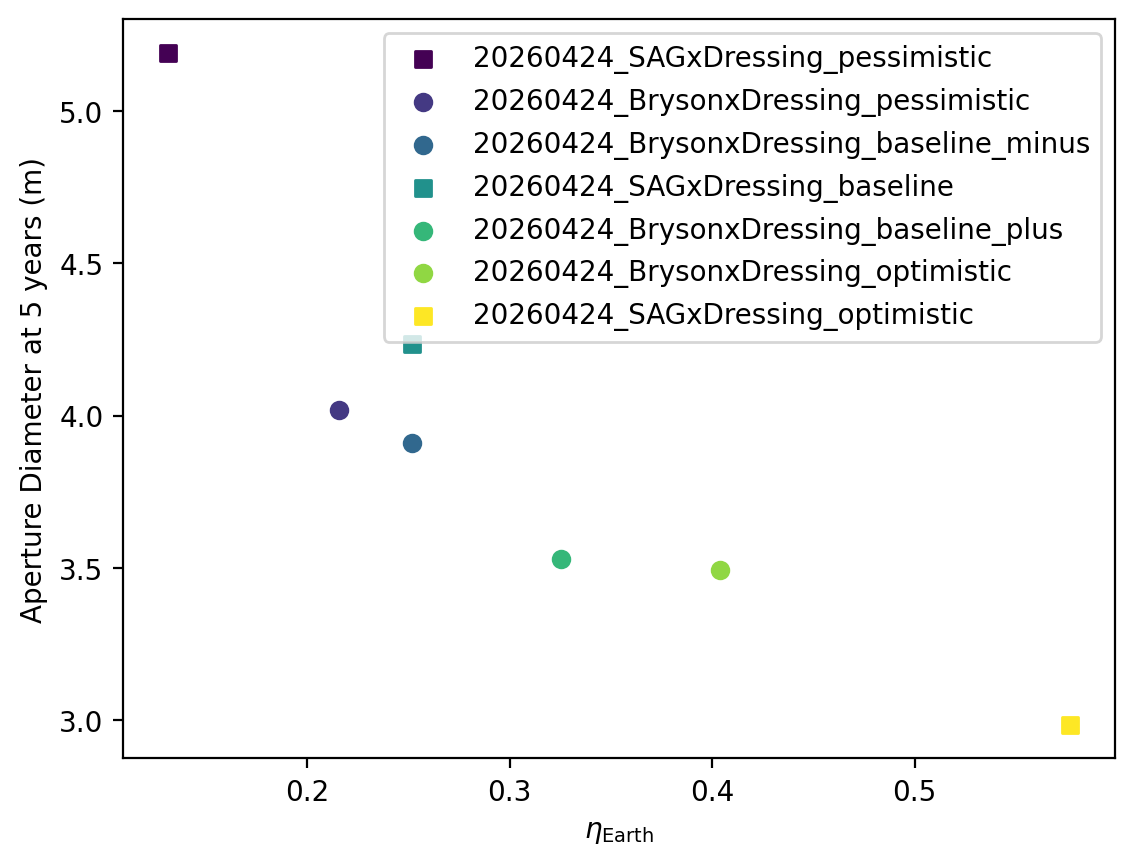

In [ ]:
fig, ax = plt.subplots(dpi=200)

# use a suitable sequential colormap
cmap = plt.get_cmap('viridis')
colors = list(cmap(np.linspace(0, 1, len(catalogs))))

for catalog in catalogs:
    c = colors.pop(0)
    try:
        if 'Bryson' in catalog:
            plt.scatter(etas.loc[catalog, 'etas_all'],
                        diam_catalogs[catalog]['e1_e2_f09_char'].loc[5.0, 'diameter_mean'],
                        marker='o',
                        label=catalog,
                        c=c)
        else:
            plt.scatter(etas.loc[catalog, 'etas_all'],
                        diam_catalogs[catalog]['e1_e2_f09_char'].loc[5.0, 'diameter_mean'],
                        marker='s',
                        label=catalog,
                        c=c)
    except:
        pass
plt.ylabel('Aperture Diameter at 5 years (m)')
plt.xlabel(r'$\eta_\mathrm{Earth}$')
plt.legend()
plt.show()

In [ ]:
bus = lifesim.Bus()

# setting the options
bus.build_from_config(filename='/Users/fdannert/Documents/projects/LIFEsim/working/master_runs/2026_January/input_catalogs/custom_config_251104_v3.yaml')
bus.data.import_catalog(input_path='/Users/fdannert/Documents/projects/LIFEsim/working/master_runs/2026_January/input_catalogs/260204_BrysonxDressing_baseline_minus/sweep_diam_3_0_catalog.hdf5')


FileNotFoundError: [Errno 2] No such file or directory: '/Users/fdannert/Documents/projects/LIFEsim/working/master_runs/2026_January/input_catalogs/custom_config_251104_v3.yaml'

In [ ]:
(bus.data.catalog.s_in,
 bus.data.catalog.s_out,
 bus.data.catalog.l_sun,
 bus.data.catalog.hz_in,
 bus.data.catalog.hz_out,
 bus.data.catalog.hz_center) = single_habitable_zone(
    model='Kopparapu-Conservative',
    # model='MS',
                                                     temp_s=bus.data.catalog.temp_s,
                                                     radius_s=bus.data.catalog.radius_s)

: 

: 

In [ ]:
bus.data.catalog.habitable = np.logical_and.reduce((
    (bus.data.catalog['semimajor_p'] > bus.data.catalog['hz_in']).to_numpy(),
    (bus.data.catalog['semimajor_p'] < bus.data.catalog['hz_out']).to_numpy(),
    (bus.data.catalog['radius_p'].ge(0.8*bus.data.catalog.semimajor_p/np.sqrt(bus.data.catalog.l_sun)**(-0.5))).to_numpy(),
    (bus.data.catalog['radius_p'].le(1.4)).to_numpy()))

# bus.data.catalog.habitable = np.logical_and.reduce((
#     (bus.data.catalog['semimajor_p'] > bus.data.catalog['hz_in']).to_numpy(),
#     (bus.data.catalog['semimajor_p'] < bus.data.catalog['hz_out']).to_numpy(),
#     (bus.data.catalog['radius_p'].ge(0.5)).to_numpy(),
#     (bus.data.catalog['radius_p'].le(1.5)).to_numpy()))

: 

: 

In [ ]:
bus.data.catalog['is_interesting'] = False
for exp in bus.data.options.optimization['experiments'].keys():
    mask_exp = ((bus.data.catalog.radius_p
                 >= bus.data.options.optimization['experiments'][exp]['radius_p_min'])
                & (bus.data.catalog.radius_p
                   <= bus.data.options.optimization['experiments'][exp]['radius_p_max'])
                & (bus.data.catalog.temp_s
                   >= bus.data.options.optimization['experiments'][exp]['temp_s_min'])
                & (bus.data.catalog.temp_s
                   <= bus.data.options.optimization['experiments'][exp]['temp_s_max']))

    if bus.data.options.optimization['experiments'][exp]['in_HZ']:
        mask_exp = (mask_exp
                    & (bus.data.catalog['habitable']))

    bus.data.catalog['exp_' + exp] = mask_exp

    bus.data.catalog['is_interesting'] = np.logical_or(mask_exp, bus.data.catalog['is_interesting'])


: 

: 

In [ ]:
np.unique(bus.data.catalog.stype)

: 

: 

In [ ]:
np.sum(bus.data.catalog.stype == 'M')

: 

: 

In [ ]:
np.sum(bus.data.catalog.habitable[bus.data.catalog.stype == 'M'])

: 

: 

In [ ]:
np.sum(bus.data.catalog.habitable[bus.data.catalog.stype == 'M']) / len(np.unique(bus.data.catalog.nstar[bus.data.catalog.stype == 'M'])) / len(np.unique(bus.data.catalog.nuniverse))

: 

: 

In [ ]:
np.sum(bus.data.catalog.is_interesting) / len(np.unique(bus.data.catalog[bus.data.catalog.is_interesting].name_s)) / len(np.unique(bus.data.catalog.nuniverse))

: 

: 

In [ ]:
plt.scatter(bus.data.catalog.temp_s[bus.data.catalog.habitable], bus.data.catalog.semimajor_p[bus.data.catalog.habitable], alpha=.01)
plt.ylim(0, 1)
plt.show()

: 

: 

In [ ]:
plt.hist(bus.data.catalog.radius_p[bus.data.catalog.stype == 'M'], bins=50, label='M')
plt.hist(bus.data.catalog.radius_p[bus.data.catalog.stype != 'M'], bins=50, label='FGK')

plt.xlabel('Radius (R_Earth)')

plt.legend()
plt.show()

: 

: 

In [ ]:
g = sns.jointplot(
    data=bus.data.catalog[bus.data.catalog.stype=='M'],
    x="semimajor_p", y="radius_p", hue='habitable',
    kind="hist",
)

: 

: 

In [ ]:
g = sns.jointplot(
    data=bus.data.catalog,
    x="semimajor_p", y="radius_p", hue='habitable',
    kind="hist",
)

plt.xlim(0, 2)

: 

: 

In [ ]:
source_path = '/Users/fdannert/Documents/projects/LIFEsim/working/master_runs/2026_January/euler_data/260204_BrysonxDressing_baseline_plus/output/'

subdirs = [d for d in os.listdir(source_path) if os.path.isdir(os.path.join(source_path, d)) if d.startswith('opt_')]
opt_names = [d.removeprefix('opt_') for d in subdirs]

diam_time_tables = {}
for subdir, opt_name in zip(subdirs, opt_names):
    data_path = os.path.join(source_path, subdir)
    diam_time_tables[opt_name] = pd.read_csv(os.path.join(data_path, subdir + '_diameter_mission_time.csv'), index_col=0)
    diam_time_tables[opt_name][diam_time_tables[opt_name] < 0] = np.nan  # set negative values to nan

# sort opt_name by mean diameter at 10 years
diam_time_tables = dict(sorted(diam_time_tables.items(), key=lambda item: item[1].loc[10, 'diameter_mean']))

: 

: 

In [ ]:
diam_time_tables['e1_f05_char'].columns

: 

: 

In [ ]:
fig, ax = plt.subplots(dpi=200)

# use a suitable sequential colormap
cmap = plt.get_cmap('viridis')
colors = list(cmap(np.linspace(0, 1, len(diam_time_tables))))

for opt_name, table in diam_time_tables.items():
    c = colors.pop(0)
    plt.plot(table.index, table['diameter_mean'], label=opt_name, color=c)
    # plt.fill_between(table.index,
    #                  table['diameter_mean'] - table['lu_diameter'],
    #                  table['diameter_mean'] + table['uu_diameter'],
    #                  alpha=0.3,
    #                  color=c,)
plt.xlabel('Mission Time (years)')
plt.ylabel('Aperture Diameter (m)')
plt.legend()
plt.show()

: 

: 

In [ ]:
source_path = '/Users/fdannert/Documents/projects/LIFEsim/working/master_runs/2026_January/euler_data/260204_BrysonxDressing_baseline_minus/output/opt_e2_f05_char/'

: 

: 

In [ ]:
subdirs = [d for d in os.listdir(source_path) if os.path.isdir(os.path.join(source_path, d))]
diams_float = [float('.'.join(d.split('_')[1:])) for d in subdirs]
diams = ['_'.join(d.split('_')[1:]) for d in subdirs]

: 

: 

In [ ]:
# uu = upper uncertainty, lu = lower uncertainty
mission_time = pd.DataFrame(index=np.sort(diams_float), columns=['mission_time_mean', 'lu_mission_time', 'uu_mission_time', 'mission_time_opt_factor'])

: 

: 

In [ ]:
for subdir, d in zip(subdirs, diams_float):
    data_path = os.path.join(source_path, subdir)
    # read the csv file in data path that ends with _mission_time.csv, return error if multiple or none found
    csv_files = [f for f in os.listdir(data_path) if f.endswith('_mission_time.csv')]
    if len(csv_files) != 1:
        raise ValueError(f'Expected one _mission_time.csv file in {data_path}, found {len(csv_files)}')
    data = pd.read_csv(os.path.join(data_path, csv_files[0]))
    mission_time.loc[d, 'mission_time_mean'] = data['total'].mean()
    mission_time.loc[d, 'lu_mission_time'] = data['total'].mean() - data['total'].quantile(0.16)
    mission_time.loc[d, 'uu_mission_time'] = data['total'].quantile(0.84) - data['total'].mean()
    det_ratio = data['detection'] / (data['orbit'] + data['characterization'])
    mission_time.loc[d, 'detection_ratio_mean'] = det_ratio.mean()
    mission_time.loc[d, 'lu_detection_ratio'] = det_ratio.mean() - det_ratio.quantile(0.16)
    mission_time.loc[d, 'uu_detection_ratio'] = det_ratio.quantile(0.84) - det_ratio.mean()

    if 'n_Experiment_1' in data.columns:
        mission_time.loc[d, 'mission_time_opt_factor'] = data.loc[data['n_Experiment_1'] == data['n_Experiment_1'].max(), 'total'].mean()
    else:
        mission_time.loc[d, 'mission_time_opt_factor'] = data.loc[data['n_Experiment_2'] == data['n_Experiment_2'].max(), 'total'].mean()

    # mission_time.loc[float(d)] = [data['mission_time'].values[0],
    #                               data['mission_time_lower_uncertainty'].values[0],
    #                               data['mission_time_upper_uncertainty'].values[0]]

: 

: 

In [ ]:
(data['detection'] / (data['orbit'] + data['characterization'])).mean()

: 

: 

In [ ]:
fig, ax = plt.subplots(dpi=200)

plt.plot(mission_time.index, mission_time['mission_time_mean'] / 365.25 / 24 / 60 / 60, label='Mean Mission Time', c='k')
plt.fill_between(list(mission_time.index),
                 list((mission_time['mission_time_mean'] - mission_time['lu_mission_time']) / 365.25 / 24 / 60 / 60),
                 list((mission_time['mission_time_mean'] + mission_time['uu_mission_time']) / 365.25 / 24 / 60 / 60),
                 color='gray', alpha=0.5, label='68% Confidence Interval')
plt.plot(mission_time.index, mission_time['mission_time_opt_factor'] / 365.25 / 24 / 60 / 60, label='Opt. Factor Mission Time', linestyle='--', c='tab:orange')
plt.xlabel('Aperture Diameter (m)')
plt.ylabel('Mission Time (years)')
plt.title('Mission Time vs Aperture Diameter')
plt.legend()

# plt.xscale('log')
plt.yscale('log')

plt.axhline(y=10, color='k', linestyle=':')
plt.axhline(y=5, color='k', linestyle=':')

plt.show()

: 

: 

In [ ]:
np.array(mission_time['mission_time_mean'] / 365.25 / 24 / 60 / 60, dtype=float)

: 

: 

In [ ]:
max_times = np.arange(0.5, 20.1, 0.5)

max_time_table = pd.DataFrame(index=np.sort(max_times), columns=['diameter_mean', 'lu_diameter', 'uu_diameter', 'diameter_opt_factor'])

# make a spline interpolation of all data points in mission time data frame and evaluate at max_times
spline = interp1d(np.array(mission_time['mission_time_mean'] / 365.25 / 24 / 60 / 60, dtype=float), np.array(mission_time.index, dtype=float), kind='cubic', fill_value='extrapolate')
max_time_table['diameter_mean'] = spline(max_times)
# for uncertainties, do linear interpolation of upper and lower bounds
spline_lu = interp1d(np.array((mission_time['mission_time_mean'] - mission_time['lu_mission_time']) / 365.25 / 24 / 60 / 60, dtype=float), np.array(mission_time.index, dtype=float), kind='linear', fill_value='extrapolate')
spline_uu = interp1d(np.array((mission_time['mission_time_mean'] + mission_time['uu_mission_time']) / 365.25 / 24 / 60 / 60, dtype=float), np.array(mission_time.index, dtype=float), kind='linear', fill_value='extrapolate')
max_time_table['lu_diameter'] = max_time_table['diameter_mean'] - spline_lu(max_times)
max_time_table['uu_diameter'] = spline_uu(max_times) - max_time_table['diameter_mean']
# for optimal factor diameters
spline_opt = interp1d(np.array(mission_time['mission_time_opt_factor'] / 365.25 / 24 / 60 / 60, dtype=float), np.array(mission_time.index, dtype=float), kind='cubic', fill_value='extrapolate')
max_time_table['diameter_opt_factor'] = spline_opt(max_times)

: 

: 

In [ ]:
max_time_table

: 

: 

In [ ]:
diameters_at_max_times

: 

: 

In [ ]:
data.sort_values(by='n_Experiment_1', ascending=False)

: 

: 

In [ ]:
plt.scatter(data.total / 365.25 / 24 / 60 / 60, data.n_Experiment_1)
plt.xlabel('Mission Time (years)')
plt.ylabel('Number of Experiment 1 Char.')
plt.show()

: 

: 

In [ ]:
np.sum(data.n_Experiment_1 == 50)

: 

: 

In [ ]:
config_path = '/Users/fdannert/Documents/projects/LIFEsim/working/master_runs/2026_January/input_catalogs/custom_config_251104_v3.yaml'
catalog_path = '/Users/fdannert/Documents/projects/LIFEsim/working/master_runs/2026_January/input_catalogs/260204_BrysonxDressing_baseline_minus/sweep_diam_3_0_catalog.hdf5'

bus = lifesim.Bus()

# setting the options
bus.build_from_config(filename=config_path)
bus.data.import_catalog(input_path=catalog_path)

print(np.sum(bus.data.catalog.habitable[bus.data.catalog.stype == 'M']))
print(np.sum(bus.data.catalog.habitable[bus.data.catalog.stype != 'M']))


(bus.data.catalog.s_in,
 bus.data.catalog.s_out,
 bus.data.catalog.l_sun,
 bus.data.catalog.hz_in,
 bus.data.catalog.hz_out,
 bus.data.catalog.hz_center) = single_habitable_zone(model='MS',
                                                     temp_s=bus.data.catalog.temp_s,
                                                     radius_s=bus.data.catalog.radius_s)

print(np.sum(bus.data.catalog.habitable[bus.data.catalog.stype == 'M']))
print(np.sum(bus.data.catalog.habitable[bus.data.catalog.stype != 'M']))

: 

: 

: 

: 